In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = fetch_california_housing(as_frame=True)
x = data.data
y = data.target

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [13]:
ridge = Ridge(alpha=1)
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)

In [14]:
lasso = Lasso(alpha=0.1)
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_test_scaled)

In [16]:
print("Ridge MSE", mean_squared_error(y_test, y_pred_ridge))
print("Lasso MSE", mean_squared_error(y_test, y_pred_lasso))
print("R2 score Ridge", r2_score(y_test, y_pred_ridge))
print("R2 score Lasso", r2_score(y_test, y_pred_lasso))

Ridge MSE 0.5388497008369689
Lasso MSE 0.678403213308178
R2 score Ridge 0.5887927282363985
R2 score Lasso 0.48229657719617414


In [19]:
results = pd.DataFrame({"Feature": x.columns, "Ridge Coef": ridge.coef_, "Lasso Coef": lasso.coef_})
print(results)

      Feature  Ridge Coef  Lasso Coef
0      MedInc    0.854327    0.710598
1    HouseAge    0.122624    0.106453
2    AveRooms   -0.294210   -0.000000
3   AveBedrms    0.339008    0.000000
4  Population   -0.002282   -0.000000
5    AveOccup   -0.040833   -0.000000
6    Latitude   -0.896168   -0.011469
7   Longitude   -0.869071   -0.000000


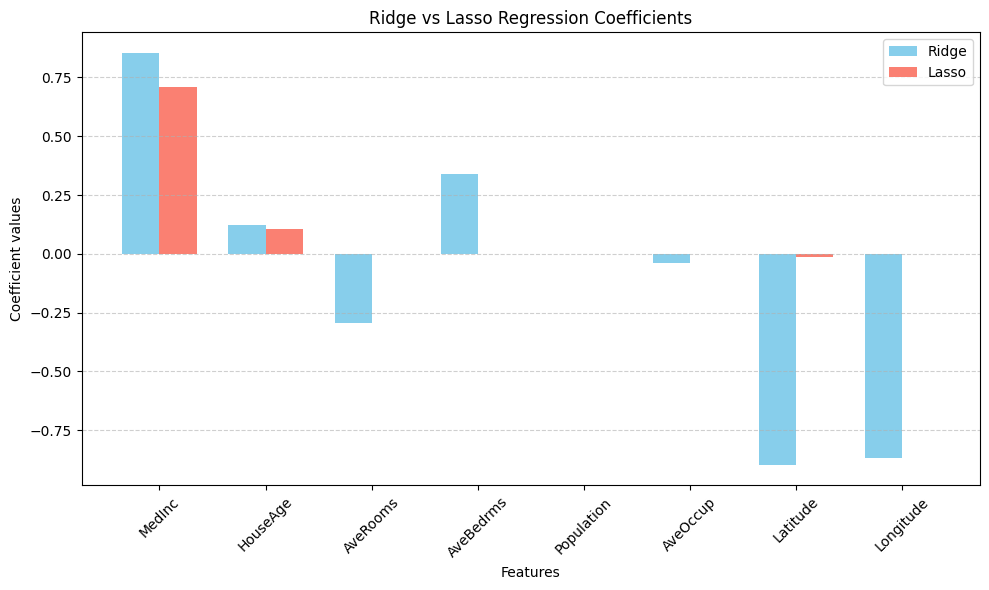

In [21]:
plt.figure(figsize=(10, 6))

x = np.arange(len(results['Feature']))
width = 0.35

plt.bar(x - width/2, results['Ridge Coef'], width, label='Ridge', color='skyblue')
plt.bar(x + width/2, results['Lasso Coef'], width, label='Lasso', color='salmon')

plt.xlabel('Features')
plt.ylabel('Coefficient values')
plt.title('Ridge vs Lasso Regression Coefficients')
plt.xticks(x, results['Feature'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

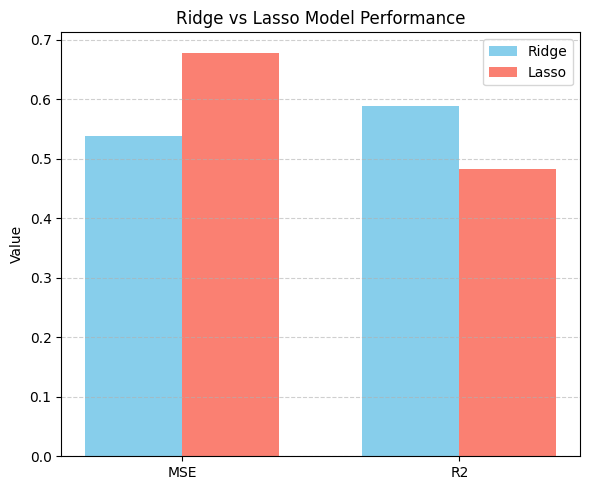

In [22]:
metrics = ['MSE', 'R2']
ridge_values = [mean_squared_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)]
lasso_values = [mean_squared_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(6, 5))
plt.bar(x - width/2, ridge_values, width, label='Ridge', color='skyblue')
plt.bar(x + width/2, lasso_values, width, label='Lasso', color='salmon')

plt.ylabel('Value')
plt.title('Ridge vs Lasso Model Performance')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()